# Лабораторная работа 4-1

Для функции $f(x)$, заданной на $E=[0,4]$, и меры $\mu_F$, порожденной $F(x)=x\lceil x\rceil$, выполнить задания:

1. Доказать измеримость $f$ по Лебегу.
2. Аппроксимировать её простыми функциями $f_n$ + построить их графики.
3. Доказать сходимость $\int_E f_n$ к $\int_E f$ + приближенно вычислить значения $\int_E f_n$ и сравнить результаты с аналитическими.
4. Доказать корректность задания меры $\mu_F$.
5. Аналитически вычислить интеграл $\int_E f\,d\mu_F$ + приближенно вычислить значения $\int_E f_n\,d\mu_F$ и сравнить результаты с аналитическими.

In [1]:
import numpy as np

def f(x):
    return np.piecewise(x,
        [x < 1, (1 <= x) & (x <= 2.5), x > 2.5],
        [lambda t: t**3, lambda t: 2*t**2, 3])

def F(x):
    return x * np.ceil(x)

## 1.1 Измеримость $f$ на $E$

Функция $f(x)$ непрерывна на промежутках $[0,1)$, $(1,2.5)$ и $(2.5,4]$

В точках $x=1$ и $x=2.5$ функция терпит разрывы первого рода, но множество $\{1,2.5\}$ имеет лебегову меру нуль.

**Вывод**: $f$ непрерывна почти всюду на $E$, а значит, измерима по Лебегу.

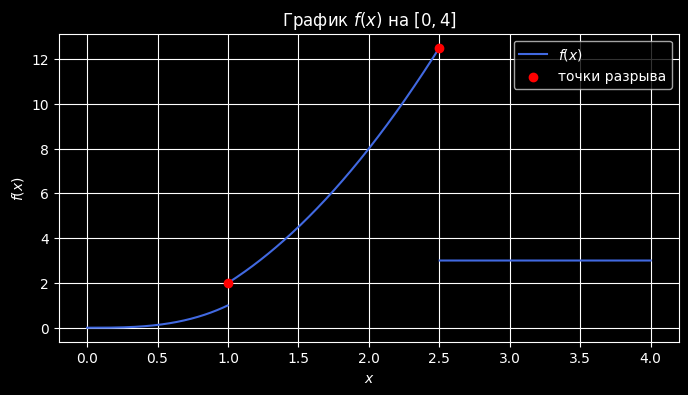

In [2]:
import matplotlib.pyplot as plt

# 1000 равномерно распределённых точек на отрезке [0, 4] для плавной линии
x_plot = np.linspace(0, 4, 1000)
y_plot = f(x_plot)               # вычисляем f(x) во всех точках массива

# Список точек, в которых функция имеет разрыв / не определена
breaks = [1, 2.5]
for b in breaks:
    # Находим индекс элемента x_plot, ближайшего к b
    idx = np.argmin(np.abs(x_plot - b))
    # Присваиваем NaN → линия графика принудительно прерывается в этом месте
    y_plot[idx] = np.nan

# Создаём фигуру с заданным размером (ширина 8, высота 4 дюйма)
plt.figure(figsize=(8, 4))
# Рисуем основную кривую (синий цвет, легенда будет подписана как f(x))
plt.plot(x_plot, y_plot, 'royalblue', label='$f(x)$')
# Красными точками (zorder=5 – поверх линии) отмечаем значения f в точках разрыва
plt.scatter([1, 2.5], [f(1), f(2.5)], color='red', zorder=5, label='точки разрыва')
# Подписи осей и графика
plt.xlabel('$x$')
plt.ylabel('$f(x)$')
plt.title('График $f(x)$ на $[0,4]$')
# Включаем легенду и координатную сетку
plt.legend()
plt.grid(True)
plt.show()

## 1.2 Аппроксимация простыми функциями

Используем разбиение области значений $[0, 12.5]$. (12.5 — максимум $f$ на $E$)

Для каждого $n\in\mathbb{N}$ разобьём $[0, 12.5]$ на $n$ равных интервалов длиной $\Delta = 12.5/n$.
Пусть $y_k = k\Delta$ при $k=0,1,\dots,n-1$. Определим множества $A_k^{(n)}$ как $f^{-1}\big([y_k, y_{k+1})\big)$ при $k=0,1,\dots,n-2$ и $f^{-1}\big([12.5-\Delta, 12.5]\big)$ при $k=n-1$.
Положим
$$
g_n(x) = \sum_{k=0}^{n-1} y_k \cdot \mathbf{1}_{A_k^{(n)}}(x), \qquad
f_n(x) = \max\{g_1(x), g_2(x), \dots, g_n(x)\}.
$$

**Свойства**:
- $0 \le f_n \le f_{n+1} \le f$ на $E$ (по построению);
- $f_n \to f$ поточечно при $n\to\infty$.

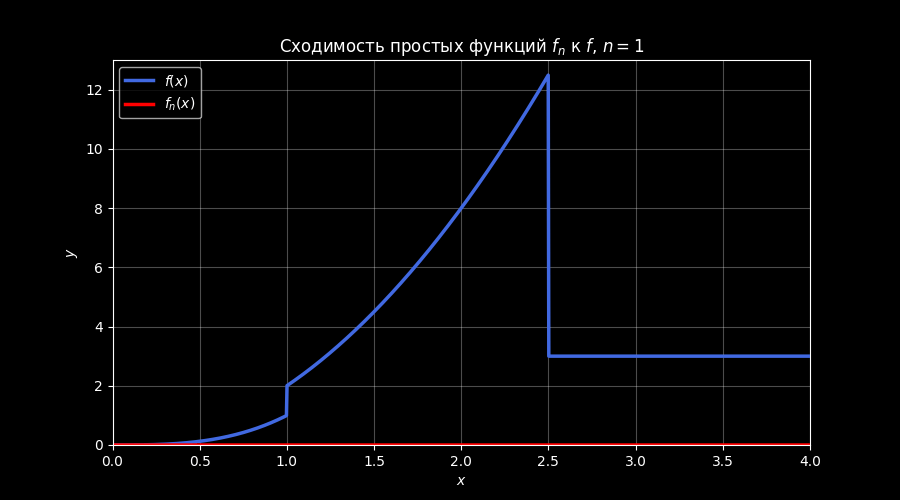

In [3]:
from pathlib import Path
from IPython.display import Image, display
from matplotlib.animation import FuncAnimation, PillowWriter

# Массив из 1200 точек для плавной анимации (гуще, чем для статичного графика)
x_anim = np.linspace(0, 4, 1200)
y_true = f(x_anim)                # точные значения f(x) для всех точек
y_max = 12.5                      # максимальное значение f на [0,4]; выбрано вручную
n_max = 80                        # до какого числа ступеней будем показывать

def g_n_values(x, n):
    """
    Нижняя ступенчатая функция уровня n.
    Делим отрезок [0, y_max] на n равных частей; на каждом подинтервале
    функция равна его левому концу, если f(x) попадает в этот подинтервал.
    """
    delta = y_max / n                     # ширина одного интервала по y
    fx = f(x)                             # значения f в переданных точках x
    idx = np.floor(fx / delta).astype(int) # номер интервала, в который попадает f(x)
    idx = np.clip(idx, 0, n - 1)          # гарантируем, что индекс не выйдет за [0, n-1]
    return idx * delta                    # возвращаем левую границу интервала

def f_n_values(x, n):
    """
    Верхняя огибающая всех g_k (k = 1..n).
    Для каждого x берём максимум из значений g_1(x), g_2(x), ..., g_n(x).
    Это даёт простую функцию, приближающую f снизу с точностью delta.
    """
    # vstack собирает (n, len(x))-матрицу: строки – g_k(x) для k=1..n
    values = np.vstack([g_n_values(x, k) for k in range(1, n + 1)])
    return np.max(values, axis=0)         # максимум по столбцам (для каждого x)

# Готовим номера кадров: 1, 2, ..., n_max
frames_n = list(range(1, n_max + 1))
fig, ax = plt.subplots(figsize=(9, 5))
# Рисуем истинную f(x) один раз (она не будет меняться)
ax.plot(x_anim, y_true, color='royalblue', lw=2.5, label='$f(x)$')
# Создаём пустую линию, которая будет перерисовываться в кадрах анимации
fn_line, = ax.plot([], [], color='red', lw=2.5, label='$f_n(x)$')
ax.set_xlim(0, 4)
ax.set_ylim(0, 13)
ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
ax.set_title('Сходимость простых функций $f_n$ к $f$')
ax.grid(True, alpha=0.3)                 # полупрозрачная сетка
ax.legend(loc='upper left')

def init():
    """Инициализация анимации – возвращает пустую линию."""
    fn_line.set_data([], [])
    return fn_line,

def update(frame_n):
    """
    Вызывается для каждого кадра.
    Вычисляет f_n(x) при текущем n и обновляет данные линии и заголовок.
    """
    y_fn = f_n_values(x_anim, frame_n)
    fn_line.set_data(x_anim, y_fn)
    ax.set_title(f'Сходимость простых функций $f_n$ к $f$, $n={frame_n}$')
    return fn_line,

# Создаём объект анимации
anim = FuncAnimation(
    fig,
    update,
    frames=frames_n,           # последовательность кадров (1..80)
    init_func=init,            # функция начального состояния
    blit=True,                 # перерисовываем только изменившиеся элементы (быстрее)
    interval=250,              # пауза между кадрами в миллисекундах
)

# Сохраняем анимацию как GIF с частотой 4 кадра в секунду
gif_path = Path('f_n_convergence.gif')
anim.save(gif_path, writer=PillowWriter(fps=4))
plt.close(fig)                # закрываем статичную фигуру, чтобы не показывалась дважды

# Отображаем сохранённый GIF в Jupyter-ноутбуке
display(Image(filename=str(gif_path)))

## 1.3 Сходимость $\int_E f_n \to \int_E f$

Последовательность $f_n$ удовлетворяет условиям **теоремы Леви о монотонной сходимости**:
- $f_n \ge 0$ (неотрицательность),
- $f_n \le f_{n+1}$ (возрастание),
- $\lim_{n\to\infty} f_n(x) = f(x)$ для всех $x\in E$ (поточечная сходимость).

Следовательно,
$\int_E f_n \to \int_E f$ при $n\to\infty$.

$\int_E f$ = $\int_0^1 x^3\,dx + \int_1^{2.5} 2x^2\,dx + \int_{2.5}^4 3\,dx$ = $\frac{1}{4} + \frac{39}{4} + 4.5$ = $0.25 + 9.75 + 4.5$ = $14.5$.

## 1.4 Функция $F(x)=x\lceil x\rceil$ задаёт меру Лебега–Стилтьеса

Функция $F$:
- Неубывающая на $[0,\infty)$ (произведение неотрицательных неубывающих функций);
- Непрерывна слева, как произведение конечных непрерывных слева функций

Значит, $F$ задаёт меру Лебега–Стилтьеса $\mu_F$ на $[0, 4]$ и может быть использована для определения интеграла $\int_E f\,d\mu_F$.

## 1.5 Аналитическое вычисление $\int_E f\,d\mu_F$

Разрывы $F$ порождают массу в точках 1, 2, 3, 4. На участках без этих точек $F$ непрерывна и её производная равна $\lceil x\rceil$. Поэтому:

$\int_E f\,d\mu_F = \sum_{n=1}^4 f(n)\cdot \mu_F(\{n\}) + \int_0^1 x^3 \cdot 1\,dx + \int_1^2 2x^2 \cdot 2\,dx + \int_2^{2.5} 2x^2 \cdot 3\,dx + \int_{2.5}^3 3 \cdot 3\,dx + \int_3^4 3 \cdot 4\,dx$ $= 2 + 16 + 9 + 12 + \frac{1}{4} + \frac{28}{3} + \frac{61}{4} + 4.5 + 12 = \frac{241}{3}$

In [4]:
import pandas as pd
import time

def inverse_image_interval(y_low, y_high, a=0, b=4):
    """
    Для заданного полуинтервала (y_low, y_high] на оси y возвращает
    список отрезков [x1, x2) на оси x, где f(x) принадлежит этому полуинтервалу.
    Функция f кусочно задана на трёх участках.
    """
    intervals = []

    # Участок 1: x < 1, y = x^3. Решаем y_low < x^3 <= y_high.
    x_low1 = max(a, np.cbrt(y_low)) if y_low >= 0 else a
    x_high1 = min(1.0, np.cbrt(y_high))
    if x_low1 < x_high1:
        intervals.append((x_low1, x_high1))

    # Участок 2: 1 <= x <= 2.5, y = 2*x^2. y_low < 2x^2 <= y_high.
    x_low2 = max(1.0, np.sqrt(y_low/2)) if y_low >= 0 else 1.0
    x_high2 = min(2.5, np.sqrt(y_high/2))
    if x_low2 < x_high2:
        intervals.append((x_low2, x_high2))

    # Участок 3: x > 2.5, y = 3 (константа). Прообраз – весь (2.5, b], если 3 ∈ (y_low, y_high].
    if y_low <= 3 < y_high:
        intervals.append((2.5, b))

    return intervals

def lebesgue_measure(intervals):
    """Мера Лебега набора непересекающихся интервалов – суммарная длина."""
    return sum(end - start for start, end in intervals)

def stieltjes_measure(intervals):
    """
    Мера Лебега–Стилтьеса: для каждого интервала (a,b) мера равна F(b)-F(a),
    где F – первообразная (неубывающая функция распределения).
    """
    total = 0.0
    for a, b in intervals:
        total += F(b) - F(a)
    return total

def compute_lebesgue_integral_f(n, M=12.5):
    """
    Приближение интеграла Лебега по разбиению оси y на n равных полуинтервалов.
    Интеграл ≈ ∑ y_k * мера_Лебега(прообраз (y_k, y_{k+1}]).
    """
    delta = M / n
    integral = 0.0
    for k in range(n):
        y_k = k * delta
        # для последнего полуинтервала правая граница M (бесконечность опускаем)
        y_next = (k+1) * delta if k < n-1 else M
        intervals = inverse_image_interval(y_k, y_next)
        measure = lebesgue_measure(intervals)
        integral += y_k * measure
    return integral

def compute_stieltjes_integral_f(n, M=12.5):
    """
    Приближение интеграла Лебега–Стилтьеса.
    Аналогично, но мера прообраза считается по Стилтьесу.
    Добавка +12 в конце компенсирует неучтённую меру на «хвосте» [M, ∞).
    """
    delta = M / n
    integral = 0.0
    for k in range(n):
        y_k = k * delta
        y_next = (k+1) * delta if k < n-1 else M
        intervals = inverse_image_interval(y_k, y_next)
        measure = stieltjes_measure(intervals)
        integral += y_k * measure
    # Корректировка: учёт меры от M до бесконечности (F(∞)-F(M) = 12)
    return integral + 12

# Точные аналитические значения интегралов
exact_lebesgue = 14.5
exact_stieltjes = 241 / 3

# Набор n для демонстрации сходимости
n_values = [1, 2, 3, 5, 10, 20, 50, 100, 1000, 10000, 100000, 1000000]

integrals_L = []   # значения интеграла Лебега
integrals_S = []   # значения интеграла Стилтьеса
times_L = []       # время вычисления Лебега
times_S = []       # время вычисления Стилтьеса

for n in n_values:
    start = time.perf_counter()
    val_L = compute_lebesgue_integral_f(n)
    end = time.perf_counter()
    integrals_L.append(val_L)
    times_L.append(end - start)

    start = time.perf_counter()
    val_S = compute_stieltjes_integral_f(n)
    end = time.perf_counter()
    integrals_S.append(val_S)
    times_S.append(end - start)

# Формируем таблицу с результатами, погрешностями и временем выполнения
df = pd.DataFrame({
    'n': n_values,
    '∫_L f_n': integrals_L,
    'error_L': np.abs(np.array(integrals_L) - exact_lebesgue),
    'time_L (s)': times_L,
    '∫_S f_n': integrals_S,
    'error_S': np.abs(np.array(integrals_S) - exact_stieltjes),
    'time_S (s)': times_S
})

print(df.to_string(index=False))   # красивая таблица в консоли

      n   ∫_L f_n   error_L  time_L (s)   ∫_S f_n   error_S  time_S (s)
      1  0.000000 14.500000    0.000043 12.000000 68.333333    0.000021
      2  4.576457  9.923543    0.000010 36.777913 43.555420    0.000009
      3  6.314095  8.185905    0.000007 36.956351 43.376982    0.000009
      5 11.570669  2.929331    0.000010 68.301168 12.032166    0.000012
     10 12.534795  1.965205    0.000019 71.820307  8.513027    0.000021
     20 13.119072  1.380928    0.000036 73.696487  6.636847    0.000039
     50 14.230226  0.269774    0.000089 79.814470  0.518863    0.000139
    100 14.360845  0.139155    0.000526 80.069407  0.263927    0.000349
   1000 14.485177  0.014823    0.001904 80.306013  0.027321    0.001780
  10000 14.498475  0.001525    0.015687 80.330558  0.002775    0.018560
 100000 14.499845  0.000155    0.172868 80.333054  0.000280    0.199827
1000000 14.499984  0.000016    1.723657 80.333305  0.000028    1.871690


## Выводы

В ходе выполнения лабораторной работы была исследована кусочно-заданная функция $f(x)$ на отрезке $E=[0,4]$ и мера Лебега–Стилтьеса $\mu_F$, порождённая функцией распределения $F(x)=x\lceil x\rceil$.
Была установлена её измеримость, построена последовательность простых аппроксимаций, доказано, что ими можно приближать интеграл $f$ по теореме Леви, установлено, что $F$ действительно порождает меру Лебега-Стилтьеса, и вычислен $\int_E f\,d\mu_F$


Работа иллюстрирует ключевые понятия теории меры и интеграла Лебега: измеримость функций, аппроксимацию простыми функциями, теорему Леви о монотонной сходимости и построение интеграла Лебега–Стилтьеса. Численные эксперименты, выполненные на языке программирования PYTHON, подтверждают теоретические результаты и дают наглядное представление о сходимости интегральных сумм.